In [7]:
# ==========================================================
# Butterfly Image Classification - Regularization Techniques
# ==========================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================================================
# Configuración
# ==========================================================
device = torch.device('cpu')
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

data_dir = "C:/Users/saygu/IA/2-25-SIS420/Laboratorios/Lab 6/data/"

batch_size = 64
learning_rate = 0.001
num_epochs = 50
patience = 10   # paciencia para early stopping


Usando dispositivo: cpu


In [8]:
# ==========================================================
# Transformaciones con Data Augmentation
# ==========================================================
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),   # voltear imagen horizontalmente con 50% probabilidad
    transforms.RandomRotation(10),            # rotar hasta ±10 grados
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # variaciones de brillo/contraste
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [9]:
# ==========================================================
# Dataset y Dataloader
# ==========================================================
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

num_classes = len(train_dataset.classes)
print("Número de clases:", num_classes)
print("Ejemplos de entrenamiento:", len(train_dataset))
print("Ejemplos de validación:", len(val_dataset))


Número de clases: 100
Ejemplos de entrenamiento: 12594
Ejemplos de validación: 500


In [10]:
# ==========================================================
# Definir MLP con Dropout
# ==========================================================
class MLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, num_classes):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(hidden2, num_classes)
    
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

input_size = 64*64*3
model = MLP(input_size, 256, 128, num_classes).to(device)


In [11]:
# ==========================================================
# Función de pérdida y optimizador
# ==========================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
# ==========================================================
# Entrenamiento con Early Stopping (simplificado)
# ==========================================================
best_val_loss = np.inf
counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Validación
    model.eval()
    running_val_loss = 0.0
    correct_val, total_val = 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
    
    val_loss = running_val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")
    
    # Early stopping sencillo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping activado.")
            model.load_state_dict(best_model_wts)
            break


Epoch [1/50] | Train Loss: 4.2113, Val Loss: 3.5780 | Train Acc: 5.96%, Val Acc: 13.40%
Epoch [2/50] | Train Loss: 3.6575, Val Loss: 3.1288 | Train Acc: 12.36%, Val Acc: 20.20%
Epoch [3/50] | Train Loss: 3.3938, Val Loss: 2.9721 | Train Acc: 17.14%, Val Acc: 25.40%
Epoch [4/50] | Train Loss: 3.2356, Val Loss: 2.9350 | Train Acc: 20.36%, Val Acc: 24.60%
Epoch [5/50] | Train Loss: 3.1315, Val Loss: 2.7449 | Train Acc: 22.17%, Val Acc: 30.60%
Epoch [6/50] | Train Loss: 3.0331, Val Loss: 2.7348 | Train Acc: 24.36%, Val Acc: 29.60%
Epoch [7/50] | Train Loss: 2.9780, Val Loss: 2.6271 | Train Acc: 24.81%, Val Acc: 32.60%
Epoch [8/50] | Train Loss: 2.8860, Val Loss: 2.5698 | Train Acc: 26.39%, Val Acc: 32.20%
Epoch [9/50] | Train Loss: 2.8714, Val Loss: 2.5123 | Train Acc: 27.28%, Val Acc: 38.60%
Epoch [10/50] | Train Loss: 2.8096, Val Loss: 2.5204 | Train Acc: 28.91%, Val Acc: 36.00%
Epoch [11/50] | Train Loss: 2.7727, Val Loss: 2.4922 | Train Acc: 29.28%, Val Acc: 33.80%
Epoch [12/50] | Trai

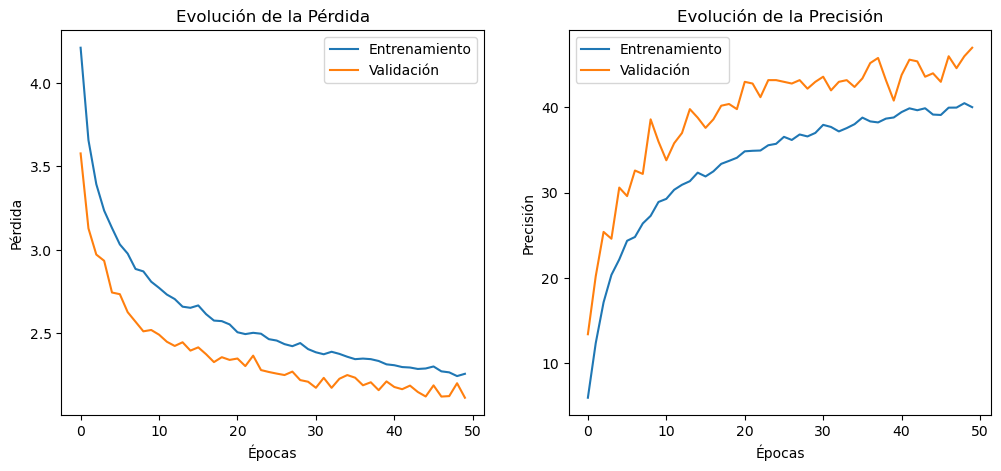

In [13]:
# ==========================================================
# Gráficos de pérdida y precisión
# ==========================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Entrenamiento")
plt.plot(val_losses, label="Validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la Pérdida")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Entrenamiento")
plt.plot(val_accuracies, label="Validación")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.title("Evolución de la Precisión")
plt.legend()

plt.show()

